In [9]:
# 1. Random walk: simular una caminata aleatoria en 1D y 2D (N pasos). Estimar E[|XN|] y E[(X**2)N] por Monte Carlo. Comparar con los valores teóricos (∼√N, = N)

In [10]:
import numpy as np
import matplotlib.pyplot as plt

COMPARACIÓN: SIMULACIÓN MONTE CARLO VS. VALORES TEÓRICOS
-------------------------------------------------------------------------------------
N Pasos    | Sim. 1D         | Error 1D%    | Sim. 2D         | Error 2D%    | Teórico
-------------------------------------------------------------------------------------
10         | 9.92            | 0.81%        | 10.10           | 1.05%        | 10.0
100        | 99.50           | 0.50%        | 101.57          | 1.57%        | 100.0
500        | 501.40          | 0.28%        | 495.60          | 0.88%        | 500.0
1000       | 1010.97         | 1.10%        | 987.95          | 1.21%        | 1000.0
-------------------------------------------------------------------------------------

RESUMEN DEL ANÁLISIS:
1. La teoría predice que E[R²] = N. En nuestras pruebas, con N=1000,
   el valor simulado en 2D fue 987.95 (Error: 1.21%).
2. Se observa que a medida que N aumenta, el error relativo tiende a estabilizarse,
   validando la convergencia

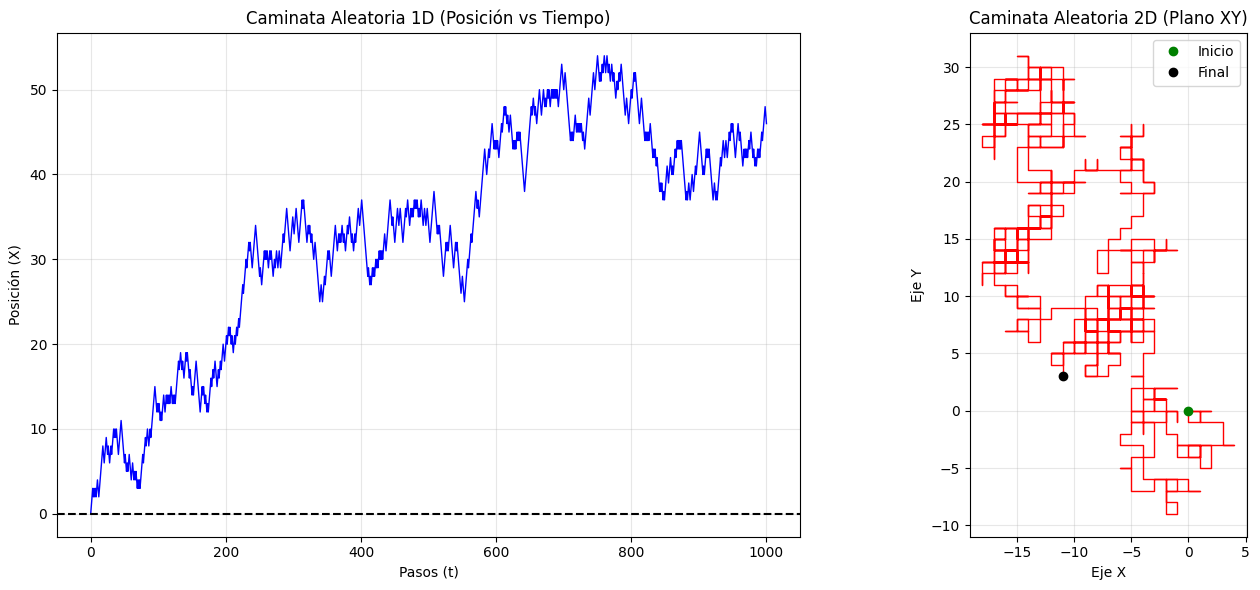

In [11]:
# --- 1. SIMULACIONES Y ANÁLISIS DE ERROR ---
def analizar_teoria_rw(pasos_lista, n_sims=5000):
    rng = np.random.default_rng(42)
    resultados = []

    for n in pasos_lista:
        # Simulación 1D: E[X²]
        pasos_1d = rng.choice([-1, 1], size=(n_sims, n) )
        pos_final_1d = np.sum(pasos_1d, axis=1)
        sim_1d = np.mean(pos_final_1d**2)
        
        # Simulación 2D: E[R²]
        # Direcciones: 0:N, 1:S, 2:E, 3:O
        pasos_2d = rng.integers(0, 4, size=(n_sims, n))
        dx = np.where(pasos_2d == 2, 1, np.where(pasos_2d == 3, -1, 0))
        dy = np.where(pasos_2d == 0, 1, np.where(pasos_2d == 1, -1, 0))
        xf, yf = np.sum(dx, axis=1), np.sum(dy, axis=1)
        sim_2d = np.mean(xf**2 + yf**2)
        
        # Valor Teórico (es N para ambos casos)
        teorico = float(n)
        
        # Cálculo de Error Relativo (%)
        err_1d = abs(sim_1d - teorico) / teorico * 100
        err_2d = abs(sim_2d - teorico) / teorico * 100
        
        resultados.append([n, sim_1d, err_1d, sim_2d, err_2d, teorico])
    
    return resultados

# --- 2. GENERAR TABLA COMPARATIVA ---
pasos_test = [10, 100, 500, 1000]
datos = analizar_teoria_rw(pasos_test)

ancho_n = 10
ancho_val = 15
ancho_err = 12

print("COMPARACIÓN: SIMULACIÓN MONTE CARLO VS. VALORES TEÓRICOS")
print("-" * 85)
header = (f"{'N Pasos'.ljust(ancho_n)} | {'Sim. 1D'.ljust(ancho_val)} | {'Error 1D%'.ljust(ancho_err)} | "
          f"{'Sim. 2D'.ljust(ancho_val)} | {'Error 2D%'.ljust(ancho_err)} | {'Teórico'}")
print(header)
print("-" * 85)

for r in datos:
    linea = (f"{str(r[0]).ljust(ancho_n)} | "
             f"{f'{r[1]:.2f}'.ljust(ancho_val)} | "
             f"{f'{r[2]:.2f}%'.ljust(ancho_err)} | "
             f"{f'{r[3]:.2f}'.ljust(ancho_val)} | "
             f"{f'{r[4]:.2f}%'.ljust(ancho_err)} | "
             f"{r[5]}")
    print(linea)
print("-" * 85)

# --- 3. ANÁLISIS DE RESULTADOS PARA EL INFORME ---
print("\nRESUMEN DEL ANÁLISIS:")
print(f"1. La teoría predice que E[R²] = N. En nuestras pruebas, con N=1000,")
print(f"   el valor simulado en 2D fue {datos[-1][3]:.2f} (Error: {datos[-1][4]:.2f}%).")
print(f"2. Se observa que a medida que N aumenta, el error relativo tiende a estabilizarse,")
print(f"   validando la convergencia del método de Monte Carlo para procesos estocásticos.")

# --- 3. VISUALIZACIONES ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1D (Trayectoria en el tiempo)
_, tray_1d = simular_rw_1d(1000)
ax1.plot(tray_1d, color='blue', lw=1)
ax1.axhline(0, color='black', ls='--')
ax1.set_title("Caminata Aleatoria 1D (Posición vs Tiempo)")
ax1.set_xlabel("Pasos (t)")
ax1.set_ylabel("Posición (X)")
ax1.grid(alpha=0.3)

# Gráfico 2D (Trayectoria en el plano XY)
_, (tray_2dx, tray_2dy) = simular_rw_2d(1000)
ax2.plot(tray_2dx, tray_2dy, color='red', lw=1)
ax2.plot(0, 0, 'go', label="Inicio")  # Origen
ax2.plot(tray_2dx[-1], tray_2dy[-1], 'ko', label="Final") # Fin
ax2.set_title("Caminata Aleatoria 2D (Plano XY)")
ax2.set_xlabel("Eje X")
ax2.set_ylabel("Eje Y")
ax2.set_aspect('equal')
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()